# Signal Model for Direction-of-Arrival Estimation
Before proceeding with any direction-of-arrival estimation algorithm, we first need to define the signal we will work with to gain a clear understanding of the data generation process and the problem domain. This is important, as many assumptions about the signal model relate to both physical and statistical properties of real-life electromagnetic (EM) waves. If any of these assumptions do not hold, our algorithms will collapse. Get ready; you will be reminded of this over and over again in the coming notebooks for each individual algorithm, along with the exact issues that the failure of a particular assumption may cause.

The signal model will depend on multiple factors: electromagnetic wave propagation, antenna characteristics, target number, presence of interference, clutter, and noise, channel and physical signal characteristics, our assumptions on all these parameters, and so on. Throughout the notebooks, we will use some generalizations for many of these parameters.

## Python Environment
These notebooks were prepared to run in simple environments requiring no more than a few very common Python modules. For this particular notebook, the only module needed is [NumPy](https://numpy.org/), a highly-capable array processing library for Python, and [Matplotlib](https://matplotlib.org/) which has extensive capabilities for drawing elegant figures on Python.

In [ ]:
# Importing necessary modules
import numpy as np;
import matplotlib.pyplot as plt;

## Direction-of-Arrival (DoA) Estimation
The *Direction-of-Arrival* (DoA) estimation problem is simply the process of finding the arrival angles of a (known or unknown) number of target signals received by a sensor array. This process usually involves figuring out the number of target signals, determining the distortions such as noise, clutter, and interfering signals (whether intentional like jamming or unintentional), analyzing the received signal according to the known characteristics of the channel, signal, and distortion, extracting information of target signals, and finally applying this information to acquire target arrival angles.

While this problem may sound trivial, it is in fact quite a big hassle to devise a useful algorithm that effectively solves the problem, especially in real-time processing. People have developed brilliant tools for this problem in the past fifty years, and yet it is still a vibrant research area in which thousands of academics push forward the limits of speed, efficiency, and accuracy.

DoA estimation is extensively used in signal processing for many applications: radar target detection and tracking, locating incoming signals in telecommunications, sonar detection in acoustic environments, satellite communication, etc. Having familiarity with the problem will help you understand the state-of-the-art algorithms that works incredibly well in the most extreme conditions.

### Parameters
Let's begin with the physical parameters that will define the target signal.

* $c$: Speed of light. In this example, assumed to be rounded to $3*10^8$ m/s.
* $f_{c}$: Carrier frequency of the target signals in Herz. For this example, we will use $5\text{ GHz}$
* $f_{s}$: Sampling rate in Herz. Naturally, it has to be larger than the carrier frequency. In this example, we will keep it pretty high, at $100\text{ GHz}$.
* $\lambda$: Wavelength of the target signals in meters. It is calculated by the classical formula: $\lambda = \frac{c}{f}$, which gives $6\text{ cm}$ in our case.

Next step is to determine the ULA parameters.

* $N$: The number of antenna elements, i.e. how many antennas our ULA has. We can choose this value as $16$.
* $T$: The number of snapshots, in other words the number of samples we acquire in one reception phase. We will just keep it a simple number like $1000$ for now.
* $K$: The number of targets. Let's assume we have three targets hitting on the receiver throughout the listening period.

Finally, let's discuss the signal power.
* SNR_db: The noise power (variance) $\sigma_n^2$ is represented in decibels (dB). However, the value we are utilizing is the total Signal-to-Noise Ratio (SNR), and the noise power is inversely proportional to this value.

$$\text{SNR} = 10\log_{10}(\frac{\sigma_n^2}{\sigma_{total}^2})$$

* S_db: In a similar manner, each target's power $\sigma_{k}^2$ is saved in an array in dB.

In [2]:
# Defining parameters
c = 3*1e8;            # The speed of light in vacuum (m/s)
f_c = 5*1e9;          # Target carrier frequency (Hz)
f_s = 100*1e9;        # Receiver sampling frequency (Hz)
wl = c/f_c            # Signal wavelenght (m)
d = wl/2;             # Antenna distance (m)

N = 16;               # Number of antennas
T = 1000;             # Number of snapshots
K = 3;                # Number of targets

S_db = [0]*K;         # Target signal power (dB)
snr_db = 10.0;        # Signal-to-Noise Ratio (dB)

## Propagation Model
In the DoA estimation problem, the most common wave propagation model we will come across is the *narrowband* and *far-field* (planar) wave propagation. What do these terms mean, and how are they relevant to both our problem and the real-world EM wave propagation?

* **Narrowband**: When we talk about a *narrowband signal*, we mean that the primary signal of interest resides on or very closely around a specific frequency in the Fourier domain. On the contrary, a *wideband signal* is a signal that populates a large spectrum in the frequency band. Practically any signal below or around bandwiths of tens of $\text{kHz}$ may be safely considered a narrowband signal.

In the case of the DoA estimation problem, even with wideband signals narrowband assumption is perfectly fine. Because in DoA estimation, we are essentially attempting to figure out the arrival angle of a signal. This arrival angle will be same regardless of the signal bandwidth, as long as we are operating on the carrier frequency $f_c$, as a lot of math in many algorithms will depend on the frequency-specific phase shifts.

* **Far-field**: Basically, we usually want to detect things that is far enough to be out of our sight (otherwise, why would we even bother with it?), which in fact simplifies the problem significantly (what other problem do you know that simplifies just by its existence?). The **Fraunhofer distance** $d_f$ gives a good rule-of-thumb in deciding what counts as *near-field* or *far-field*

$$d_f = \frac{2D^2}{\lambda}$$

Here, $\lambda$ is the signal wavelength and $D$ is the largest surface diameter, corresponding to the distance between the opposing antenna elements at both ends in the ULA. Any distance that exceeds the Fraunhofer distance follows the far-field model, letting us assume the propagation wave to be planar across the receiver array. This is an important assumption; it means that the wave geometry is simplified to a basic wavefront, allowing us to assume the same power level (although with different phase) impinging across the array.

In real scenarios, far field more often than not holds. Using the values in this example; due to the ULA design $D$ is equal to $(N-1)*\lambda/2$. Along with that and the values chosen for the signal, the Fraunhofer distance becomes $d_{f} = (N-1)^2 \lambda/2 = 6.75\text{ m}$.

### Isotropic antenna
The antenna elements in our simple array model share the characteristic of having isotropic gain pattern, meaning that the relative gain with respect to the individual antenna is exactly same in all directions (also described as $0\text{ dBi}$, meaning $0\text{ dB}$ gain in all directions with respect to the isotropic antenna). For a signal with power $P$, the radiation field of an isotropic antenna is proportional to the distance $r$.

$$\frac{P}{4\pi r}$$

While an antenna of this sort is physically impossible, it is still a useful model when coupled with other assumptions, particularly regarding the signal model such as far-field planar propagation.

We also assume that antenna elements are identical, meaning they all have perfectly same gain patterns, all elements receive the signal with the same gain, and thus distortions caused by idiosyncratic antenna gain patterns are pretty much nullified.

### Uniform Linear Array (ULA)
In this example, we will build a Uniform Linear Array (ULA). A ULA includes equidistantly spaced antenna elements on a linear grid. The distance between antenna elements $d$ for a typical ULA is usually chosen to be the half of the wavelenght $d = \lambda/2\text{ m}$. The reason we choose this distance mainly comes to the frequency resolution. Simply put, antenna elements dispersed in this configuration is best suited to capture the frequency of interest.

There are many other antenna structures used for different applications. Unfortunately, this notebook will mostly concern with the signal model, therefore we have to cut the antenna design discussion short.

### Antenna Array
Antenna position matrix $\mathbf{P} \in \mathbb{R}^{3 \times N}$ holds the values for the position of the $n^{th}$ antenna element in the 3D Cartesian coordinate system with respect to the origin point in meters.

$$
\mathbf{P} = [\mathbf{p}_{1}, ..., \mathbf{p}_{N}] \in \mathbb{R}^{3 \times N}
\\
\mathbf{p}_{n} = [p_{n,x} \hat{\mathbf{x}}, p_{n,y} \hat{\mathbf{y}}, p_{n,z} \hat{\mathbf{z}}]^{T} \in \mathbb{R}^{3 \times 1}
$$

In [ ]:
# Defining a 1D ULA over x-axis
def generate_pos_1d_ula(
    N: int,
    d: float,
    axis=(1.,0.,0.),
    x_init=(0.,0.,0.)
    ) -> np.ndarray:
  """
  Generates 3D Cartesian positions of a 1D Uniform Linear Array (ULA) across a
    given axis. The first antenna element is assumed to sit on the origin
    (0.,0.,0.) and placed on x-axis (1.,0.,0.).

  --Inputs--
  N: Number of antennas. Type of int.
  d: Distance between antennas in meters. Type of float.
  axis: The axis on which the elements are to be placed. By default
    equal to (1.,0.,0.) (x-axis). Type of tuple of 3 floats.
  x_init: Position of the initial element. By default equal to (0.,0.,0.) Type
    of tuple of 3 floats.

  --Outputs--
  sensor_pos: Antenna element positions in 3D Cartesian coordinates. Type of
    np.ndarray of size (3,N) and dtype of np.float64.
  """

  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 

sensor_pos = generate_pos_1d_ula(N, d, (1.,0.,0.), (0.,0.,0.));   # Sensor position vector

## Targets

A target in concern approaches the antenna array from a specific angle pair described as the azimuth ($\phi_k$) and elevation ($\theta_k$) angles. While this pair is useful in polar coordinates with a point of origin with a distance $r$, in the DoA estimation problem we are usually not concerned with figuring out $r$, but rather the arrival angles. By the way, if you would like to learn more about the **range estimation**, a very useful property in radar processing, check out some resources for the **Radar Range Equation**.

Target angle vector $\mathbf{\omega}_{k} \in \mathbb{R}^{3 \times 1}$ is the 3D Cartesian coordinate expression of the $k^{th}$ target's azimuth and elevation angles. In this particular case, the azimuth angle is measured clockwise over the $xy$-plane, ant the elevation angle is measured counter-clockwise over the $xz$-plane, with positive z-cardinal set as $0°$ (boresight).

$$
\mathbf{\omega}_{k} = [sin(\theta_k)cos(\phi_k), sin(\theta_k)sin(\phi_k), cos(\phi_k)]^T \in \mathbb{R}^{3 \times 1}
$$

The vector $\mathbf{\omega}_{k}$ provides more utility by allowing us calculate the phase difference caused by each target signal.

Throughout the examples discussed in the notebooks up to 2D DoA estimation, we will always assume the azimuth angle as 0. For this particular example, we will define three target angles as $60°$, $-45°$, and $10°$, respectively.

In [4]:
# Target Angle Generation
ang_azim = 0;                         # Azimuth angle (deg)
angles = np.array([60, -45, 10]);

for k in range(K):
  print(f"Target {k} arrival angle: {angles[k]:.2f}°");

Target 0 arrival angle: 60.00°
Target 1 arrival angle: -45.00°
Target 2 arrival angle: 10.00°


## Steering vector
Essentially, the target phase is the main parameter that allows us figure the target angle out. Ideally we would like to keep a constant phase shift across antenna elements with respect to the relative distance between each other. This is essentially guaranteed by the far-field approximation.

*Antenna steering vector* $\mathbf{a}(\mathbf{\omega}_{k})$ encodes the phase shift for the $k^{th}$ target occuring at each antenna element per relative distance. It is very common to find the first element of the steering vector as simply $1$, this occurs when the very first element is assumed to be sitting right at the origin of the coordinate system.

$$
\mathbf{a}(\mathbf{\omega}_{k}) = \left[ e^{j {\mathbf{p}_{1}}^T \mathbf{\omega}_{k}}, \dots, e^{j {\mathbf{p}_{N}}^T \mathbf{\omega}_{k}} \right]^{T} \in \mathbb{C} ^ {N}
$$

Antenna steering matrix $\mathbf{A} \in \mathbb{C} ^ {N \times K}$ is the concatenated form of the steering vectors for all potential targets.

$$
\mathbf{A} = \left[\mathbf{a}(\mathbf{\omega}_1), \dots, \mathbf{a}(\mathbf{\omega}_K) \right] \in \mathbb{C} ^ {N \times K}
$$

In [ ]:
# Defining the steering vector
def steering_vector(
    sensor_pos: np.ndarray,
    ang_elev: float,
    ang_azim: float,
    wavelen: float
    ) -> np.ndarray:
  """
  Generates the steering vector for a given angle in degrees.

  --Inputs--
  sensor_pos: 3D Cartesian positions of a 1D Uniform Linear Array (ULA). Type of
    np.ndarray of size (3,N) and dtype of np.float64.
  ang_elev: Elevation angle in rads. Type of float.
  ang_azim: Azimuth angle in rads. Type of float.
  wavelen: Distance between antenna elements in meters. Type of float.

  --Outputs--
  Target steering vector. Type of np.ndarray of size (N,1) and dtype np.float64.
  """
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]); 
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 

## Target Model

The target signal $s_{k}(t)$ that approaches the receiver at time $t$ is commonly modeled as zero-mean Gaussian (Normal) random variable.

"Wait a minute!" I can hear from some of you, "aren't electromagnetic waves supposed to be... a wave?" And you are right! They are indeed sinusoidal waves. However, things are rarely neat in real life, even for the simplest physical properties.

In short, while an individual electromagnetic wave propagate as a well-defined sinusoid, cumulatively many different phenomena, such as scattering, fading, multipath propagation, and target rcs discrepancies, affect both constructively and destructively on the beam of our interest, practically causing the arriving wave power to be a Gaussian random variable with its variance corresponding to the target power.

There are mainly two reasons for assuming a Normal distribution for the approaching target signals: Rayleigh fading and target scintillation.

### Rayleigh Fading
Rayleigh fading is the common fading model used in communication and signal processing for electromagnetic waves. Rayleigh fading assumes that the magnitude of a signal that has passed through a channel will randomly fade following the Rayleigh distribution (essentially the radial component of the sum of two uncorrelated Gaussian rvs), where this particular fading model takes its name from.

*The Central Limit Theorem* (CLT) states that, if there is a sufficiently large number of scatters in the channel, the channel impulse response can be modelled as a Gaussian process irrespective of the distribution of the individual components. And if there is no dominant component of the scatter, then such a process will have zero mean and phase evenly distributed between 0 and 2π radians, The envelope of the channel response ($P$) will then follow the Rayleigh distribution (with $\Omega$ is the expected value of the power envelope $E[P]$):

$$p_R(p) = \frac{2p}{\Omega}e^{-r^2/\Omega}$$

Rayleigh fading is most applicable when there is no dominant propagation along a Line-of-Sight (LoS) between the transmitter and receiver, which covers a lot of scenarios; such as urban communication channels, acoustic environments, or far-field scenarios.

### Target Scintillation
While Rayleigh fading is caused by the environment (the space between the target and the array), *target scintillation*, also known as *fading amplitude* or *Radar Cross Section fluctuation*, is caused by the geometry of the target.

If we are tracking a single, large, complex target, such as a commercial airplane, a ship, or a missile, it does not appear as a single point in space, but rather as a collection of hundreds of individual reflecting surfaces. When our array illuminates the target (or just reads the passive reflections), the total signal we receive back is the vector sum of the reflections from all these different parts of the target. If the target rotates, vibrates, or changes its aspect angle by even a fraction of a degree, the relative distances between its parts relative to the receiver array change significantly.

At $5\text{ GHz}$ (our example frequency value, assuming that you haven't changed it), a shift of just a few millimeters is enough to completely flip the phase of a reflection from constructive to destructive interference. This causes the target's apparent reflective brightness, known as its *Radar Cross Section (RCS)*, to violently fluctuate over time. This rapid fluctuation in the received signal's power is what we call *target scintillation*.

In radar and array processing literature, target scintillation is mathematically categorized using the Swerling Target Models.

* **Swerling I & II**: Swerling I and II models assume a target made of many independent, similarly sized scatterers. Guess what distribution they use to model the power fluctuations? A Rayleigh distribution (which means the signal voltage amplitude is modeled as Gaussian)! Swerling I assumes slow (scan-to-scan) fluctuation, while Swerling II assumes fast (pulse-to-pulse) fluctuation.
* **Swerling III & IV**: Swerling Model III and IV models assume that targets have one dominant reflector and many smaller ones, like a boat or a jumbo jet. These models use a Chi-squared distribution.
* We also have a **Swerling 0** (or **V**) model, standing for a non-scintillating target with a perfectly constant RCS. Unfortunately, we are not interested in this particular case, since it represents an almost impossible real-life scenario.

In a short period of time, this signal $s_{k}(t)$ impinges on the elements of the antenna array. The time period is short enough to not cause significant distortion on the signal. Instead, the propagating signal's phase shift during travel causes determines the signal power received by the subsequent antenna elements, as simulated by the steering vector $a({\theta}_{k})$.

In this regard, we will simulate the impinging signal $s_{k} (t)$ as a Normal distribution with variance ${\sigma}_{k}^2$. In the following examples, we will also mention the models where it is safe to assume a sinusoidal signal.

$$s_{k}(t) \sim \mathcal{N}(0,{\sigma}_{k}^2)$$

## Noise Model
During signal reception, the target signal is contaminated by the hardware's thermal radiation, represented as $\mathbf{\eta}(t) \in \mathbb{C}^N$. In the case of noise, each RF chain is subject to their own independent thermal noise generation, therefore the noise model is defined as a random value vector of size $N$ following zero-mean white Gaussian distribution.

$$\mathbf{\eta}(t) \sim \mathbb{C}\mathcal{N}(0,{\sigma}_{\mathbf{\eta}}^2)^{N}$$

### Thermal Noise
Also known as the Johnson-Nyquist noise, is the noise generated by the thermal emission.

The thermal noise is also called as Additive White Gaussian Noise (AWGN). The reason behind this is that regardless of the spectrum we are working with, the thermal noise will have a constant expected power spectrum across frequencies. The thermal noise is essentially the black body radiation

$$ 4k_{B}RKB $$

where $k_{B}$ is the Boltzmann constant equal to $1.380649 * 10^{-23}\text{ J/K}$, $R$ is the system resistance generating the thermal energy, $K$ is the temperature of the system in $\text{K}°$, and $B$ is the bandwidth in $\text{Hz}$. This process is defined as a Gaussian process in time, which has a flat power spectral density.

For our case, we will not deal with the intricate details of simulating the noise. Instead, we will define noise power relative to the target signal power.

## Signal Model
The final signal is the sum of all impinging targets (and maybe interferences?) with the summation of the thermal noise.

$$
x(t) = \sum_{k=1}^{K} s_{k}(t)*a({\theta}_{k}) + \mathbf{\eta}(t) \in \mathbb{C}^{N}
$$

In [ ]:
# Signal Generation
sig_amp = [np.sqrt(10**(s_db/10)) for s_db in S_db]; 
noise_amp = np.sqrt(10**(-snr_db/10)); 

signal = np.zeros((N, T), dtype=complex); 
for k, s in enumerate(sig_amp):
    s_k = (np.random.randn(1, T) + 1j * np.random.randn(1, T)) / np.sqrt(2); 
    a_k = steering_vector(sensor_pos, np.deg2rad(angles[k]), np.deg2rad(0), wl); 

    signal_received = s*(a_k @ s_k); 
    signal = signal + signal_received; 

noise = noise_amp * (np.random.randn(N,T) + 1j * np.random.randn(N,T)) / np.sqrt(2); 
signal = signal + noise; 

## Shorthand (Matrix) Description
We can add each signal elements one-by-one in data generation. However, it is very helpful to remember that we are working with multidimensional objects. For example, the final signal $\mathbf{X}$ is a complex $N \times T$ matrix, with its rows corresponding to a single antenna element and its columns being a single scan at particular time.

In the same fashion, a concatenation of the target signal arrays will generate the matrix $\mathbf{S} \in \mathbb{C}^{K \times T}$. This form can be implemented in data generation along with the matrix form of the $K$ steering vectors, also known as the *array manifold* $\mathbf{A} \in \mathbb{C} ^ {N \times K}$.

$$
\mathbf{X} = \mathbf{A}\mathbf{S} + \mathbf{Η} \in \mathbb{C}^{N \times T}
$$

In [ ]:
# Signal generation with linear algebra
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in angles]); 

S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K,T) + 1j*np.random.randn(K,T))/np.sqrt(2); 

noise_amp = np.sqrt(10**(-snr_db/10)); 
H = noise_amp * (np.random.randn(N,T) + 1j*np.random.randn(N,T))/np.sqrt(2); 

X = A @ S + H;      # Received Signal at the Array

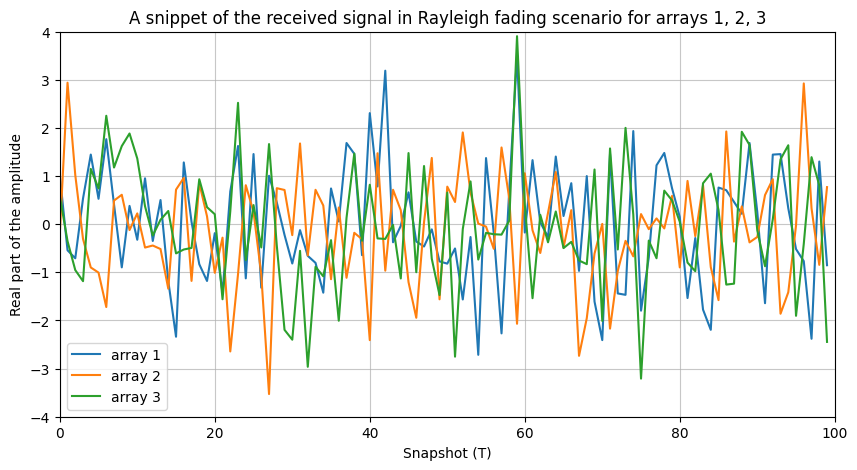

In [ ]:
plt.figure(figsize=(10,4));
plt.plot(np.arange(T)[:int(T/10)], np.real(X)[0,:int(T/10)], label="array 1"); 
plt.plot(np.arange(T)[:int(T/10)], np.real(X)[1,:int(T/10)], label="array 2"); 
plt.plot(np.arange(T)[:int(T/10)], np.real(X)[2,:int(T/10)], label="array 3"); 
plt.xlim([0, int(T/10)]); plt.ylim([-4, 4]); 
plt.title("A snippet of the received signal in Rayleigh fading scenario for arrays 1, 2, 3"); 
plt.xlabel("Snapshot (T)");plt.ylabel("Real part of the amplitude"); 
plt.grid(visible=True, alpha=0.7); 
plt.legend(loc="lower left"); 
plt.show(); 

## Rician Fading Model
Rician fading occurs when there is a clear, dominant, direct Line-of-Sight (LoS) path between the transmitter and the receiver, plus a bunch of weaker, scattered multipath signals bouncing off the surroundings.

### Power
Because there is a dominant path, the receiver gets a stable and predictable signal.The $I$ and $Q$ components are still Gaussian, but they are non-zero mean (for a given point in time) because the strong LoS component acts as a heavy, constant baseline. The amplitude of this combination results in a Ricean distribution.

Rician fading implies that there is a dominant, deterministic Line-of-Sight path plus random scattered multipath components (Rayleigh fading). This is controlled by the Rician K-factor ($K_R$), which is the ratio of the power in the LoS path to the power in the scattered paths.

$$
K_R = \frac{P_{\text{LoS}}}{P_{\text{scattered}}}
$$

* If $K_R = 0$ (linear), the dominant path completely vanishes and it degrades to standard Rayleigh fading.
* If $K_R \to \infty$, it becomes a pure, unfluctuating electromagnetic wave. The channel becomes a perfectly stable, non-fading line, plagued only by basic background receiver (thermal) noise.

### Phase
Rician fading assumes signals are coming with a non-informative random phase, emulated by the Uniform random distribution. It is a perfectly reasonable assumption when you think about the case of reception; unless you are expected to read multiple in-phase or coordinated sources, we suppose the arriving targets to have independent phases that are not centered around any particular value.

In order to simulate this behavior, we generate a constant component (LoS) and a Gaussian component (NLoS), scale them based on $K_R$, and add them together.

In [ ]:
# Rician Fading Target Generation
K_factor_db = 1000;                                 # K-factor in dB (e.g., 10 dB means LoS component's power is 10 dB higher than the NLoS one.
K_factor_lin = 10**(K_factor_db/10); 

los_amp = np.sqrt(K_factor_lin/(K_factor_lin + 1)); 
nlos_amp = np.sqrt(1 / (K_factor_lin + 1)); 

phase = np.random.uniform(0, 2*np.pi, size=(K));    # Assuming random phase
S_los = np.column_stack([np.exp(1j*2*np.pi*f_c * np.arange(0,(T-1)/f_s,1/f_s)) * np.exp(1j * phase[k]) for k in range(K)]).T; 
S_nlos = (np.random.randn(K, T) + 1j * np.random.randn(K, T)) / np.sqrt(2); 
S_rician = los_amp * S_los + nlos_amp * S_nlos; 

Sr = S_amp @ S_rician;                              # Final target matrix

noise_amp = np.sqrt(10**(-snr_db/10)); 
Hr = noise_amp * (np.random.randn(N,T) + 1j*np.random.randn(N,T))/np.sqrt(2); 

Xr = A @ Sr + Hr; 

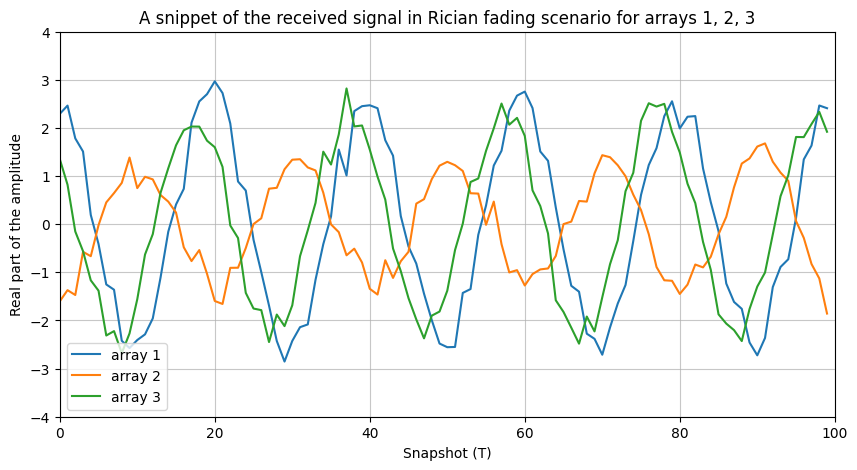

In [ ]:
plt.figure(figsize=(10,4)); 
plt.plot(np.arange(T)[:int(T/10)], np.real(Xr)[0,:int(T/10)], label="array 1"); 
plt.plot(np.arange(T)[:int(T/10)], np.real(Xr)[1,:int(T/10)], label="array 2"); 
plt.plot(np.arange(T)[:int(T/10)], np.real(Xr)[2,:int(T/10)], label="array 3"); 
plt.xlim([0, int(T/10)]); plt.ylim([-4, 4]); 
plt.title("A snippet of the received signal in Rician fading scenario for arrays 1, 2, 3"); 
plt.xlabel("Snapshot (T)");plt.ylabel("Real part of the amplitude"); 
plt.grid(visible=True, alpha=0.7); 
plt.legend(loc="lower left"); 
plt.show(); 

Rician fading is the primary model used in communication and radar systems. The main issue in digital communication is to receive the actual signal being sent, although this signal becomes extremely diminished (if you know even a little bit of RF, the power loss may approach to extreme levels as high as $-120\text{ dB}$). Therefore, the value we used for $K_c$ is in fact pretty unrealistic. However, our intention right now is just to introduce you to the concept.

## Nakagami-m Fading Model

The Nakagami-$m$ fading model was introduced by Minoru Nakagami in 1960. Unlike models derived strictly from pure geometry (like Rayleigh or Rician), the Nakagami model was originally developed empirically based on an extensive collection of experimental radio wave propagation data. Nakagami-$m$ is a highly versatile signal model, which uses the parameter $m$ to control the severity of the fading. Crucially, it can model severe fading environments (conditions worse than Rayleigh, such as severe ionospheric distortions or deep destructive interference in localized wave cavities).

In modeling a real-life signal, we deal with three parameters:

* Amplitude ($R$): The length of the signal vector in the complex plane (the absolute voltage).
* Phase ($\theta$): The angle of the signal vector.
* Power ($P$): The squared amplitude ($P = R^2$), which is proportional to the energy of the wave.

### Power and Amplitude
In a multipath environment, a receiver doesn't just receive random individual waves; it often receives clusters of waves.In statistics, squaring a standard Gaussian variable yields a Chi-squared variable (a special type of Gamma distribution). When multiple independent squared Gaussian variables (representing the energy coming from different independent scattering clusters) are summed up, the total power naturally converges to a Gamma distribution. If $m$ is an integer, a Nakagami signal can be physically interpreted as the sum of $m$ independent Rayleigh fading paths.

$$
p_P(p) = \frac{m^m p^{m-1}}{\Gamma(m) \Omega^m} \exp\left( -\frac{m p}{\Omega} \right), \quad p \ge 0
$$

The Gamma distribution is uniquely powerful because its shape parameter ($m$) allows the model to span an entire spectrum of fading conditions:

* **Severe Fading** ($m < 1$): When $m = 0.5$, the Gamma distribution becomes a Chi-squared distribution with 1 degree of freedom. This represents fading worse than Rayleigh, which happens in severe ionospheric scintillation or highly confined wave cavities where destructive interference is frequent.
* **Cluttered/No LoS** ($m = 1$): When $m = 1$, the Gamma distribution becomes an Exponential distribution. Taking its square root means the amplitude is Rayleigh distributed. This matches standard multipath (Rayleigh) fading perfectly.
* **Light Fading / Line-of-Sight** ($m > 1$): As $m$ increases beyond 1, the Gamma distribution tightens, meaning the power fluctuations become smaller and smaller. This closely maps to Rician fading (where a dominant direct line-of-sight path stabilizes the signal).
* **No Fading** ($m \to \infty$): As $m$ approaches infinity, the variance of the Gamma distribution drops to zero. The power becomes a perfectly static constant line, representing a pristine AWGN channel with zero fading.

### Phase
While the amplitude follows the Gamma distribution, the phase $\theta$ is modeled as a Uniform distribution over $[0, 2\pi)$ just like in Rician fading. The reasoning here is tied directly to the physics of electromagnetic wave propagation.

The phase of an electromagnetic wave arriving at an antenna is determined by the distance ($d$) it traveled from the transmitter, relative to its wavelength ($\lambda$):

$$\theta = \left( 2\pi \frac{d}{\lambda} \text{ mod } 2\pi \right)$$

Let's consider our notebook's setup: a carrier frequency of $5\text{ GHz}$ with $c=30*10^8\text{ m/s}$ means the wavelength $\lambda$ is exactly $6\text{ cm}$. If a wave bounces off a building and travels exactly $100\text{ meters}$, it arrives with a certain phase. However, if the wind blows a tree branch, or a car moves slightly, causing an alternative path to be $100.03\text{ meters}$ long, that tiny $3\text{ cm}$ difference shifts the phase by a massive $180^\circ$ ($\pi$ radians) ($\lambda / 2$).

Because the real world is filled with objects shifting by centimeters or meters, the distances traveled by the scattered waves are macroscopically completely random and non-informative. Coupled with the small wavelength, the resulting phases are completely scrambled and distribute themselves uniformly across the entire circle.

$$p_\Theta(\theta) = \frac{1}{2\pi}, \quad \theta \in [0, 2\pi)$$

Technically, when a strong Line-of-Sight component exists ($m > 1$), the true phase distribution starts to bunch up around the phase of the direct path (which is what happens in a strict Rician model).However, the Nakagami-$m$ model consciously chooses to decouple amplitude and phase. It forces the phase to remain uniform to keep baseband simulations and mathematical derivations tracking-friendly, while relying on the Gamma distribution to accurately capture the exact power fluctuations.

In [ ]:
# Nakagami-m Fading Target Generation
m = 2;     # The m parameter (e.g., m = 2.0 for lighter fading, m = 0.5 for severe fading)

nakagami_amp = np.sqrt(np.random.gamma(shape=m, scale=1/m, size=(K, T))); 

phase = np.random.uniform(0, 2*np.pi, size=(K, T)); 

S_nakagami = np.column_stack([nakagami_amp[k,:] * np.exp(1j*2*np.pi*f_c * np.arange(0,(T-1)/f_s,1/f_s)) * np.exp(1j * phase[k]) for k in range(K)]).T; 
Sn = S_amp @ S_nakagami; 

noise_amp = np.sqrt(10**(-snr_db/10)); 
Hn = noise_amp * (np.random.randn(N,T) + 1j*np.random.randn(N,T))/np.sqrt(2); 

Xn = A @ Sn + Hn; 

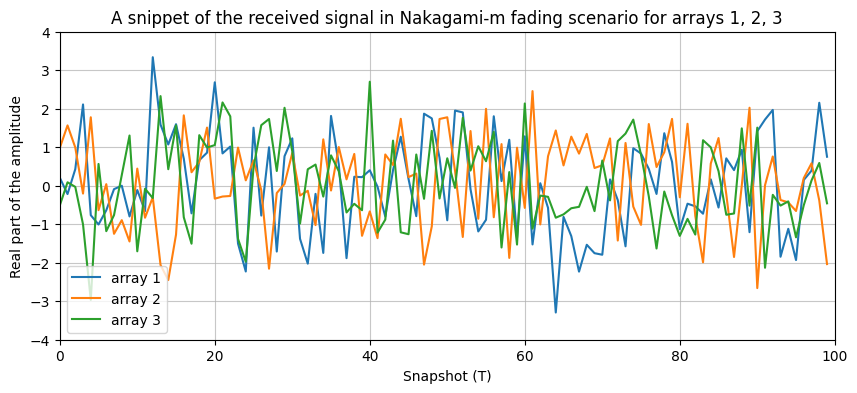

In [ ]:
plt.figure(figsize=(10,4)); 
plt.plot(np.arange(T)[:int(T/10)], np.real(Xn)[0,:int(T/10)], label="array 1"); 
plt.plot(np.arange(T)[:int(T/10)], np.real(Xn)[1,:int(T/10)], label="array 2"); 
plt.plot(np.arange(T)[:int(T/10)], np.real(Xn)[2,:int(T/10)], label="array 3"); 
plt.xlim([0, int(T/10)]); plt.ylim([-4, 4]); 
plt.title("A snippet of the received signal in Nakagami-m fading scenario for arrays 1, 2, 3"); 
plt.xlabel("Snapshot (T)");plt.ylabel("Real part of the amplitude"); 
plt.grid(visible=True, alpha=0.7); 
plt.legend(loc="lower left"); 
plt.show(); 

Does it matter that we use any of these fading models over the other in the theoretical domain? Well, kind of. Actually, using Rician fading over Rayleigh fading might imply some significant characteristics regarding the interaction between different targets. Namely, we will talk about the concerns with **uncorrelated** and **correlated** sources.

Rayleigh fading implies uncorrelated targets, meaning that once we get through the algorithms which utilize *covariance matrix* (fret not, we will go through what it exactly is), you will see that this property is extremely important. If signals happen to be more or less correlated (which happens in other fading models), this will have implications on the recovery process. Extreme cases like full correlation can even completely nullify the recovery of certain targets. Eventually, we will talk about application of different models and the mitigation of these issues.

Since we developed the common models we will use for the rest of the notebooks, you can close this page down and take a deep rest for the concepts to sit in your head. In the next notebook, we will begin with the most basic algorithm for the direction of arrival estimation, which derives from the opposite problem; *beamforming*. Stay tuned and see you next time.

## References

[Beamforming & DOA](https://pysdr.org/content/doa.html) by PySDR (check out PySDR's website as it contains amazing resources for DSP).

The original 1960 paper by Nakagami for Nakagami-$m$ Fading can be found [here](https://https://www.sciencedirect.com/science/chapter/edited-volume/abs/pii/B9780080093062500054?via%3Dihub).

[Rayleigh fading]. Wireless Communication. (http://www.wirelesscommunication.nl/reference/chaptr03/rayleigh.htm). Accessed on June 3 2026.

[Rician fading]. Wireless Communication. (http://www.wirelesscommunication.nl/reference/chaptr03/ricepdf/rice.htm). Accessed on June 3 2026.

[Nakagami fading]. Wireless Communication. (http://www.wirelesscommunication.nl/reference/chaptr03/ricenaka/nakagami.htm). Accessed on June 3 2026.



